# ML Fundamentals #2: Logistic Regression

## Binary Classification using Logistic Regression

This project demonstrates the complete implementation of Logistic Regression for solving a binary classification problem using Scikit-learn.

The notebook covers the complete machine learning workflow, including:

- Data Loading
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Training
- Prediction
- Model Evaluation
- Confusion Matrix
- ROC Curve
- Model Serialization

The objective is to understand how Logistic Regression models probabilities for binary outcomes and how its performance is evaluated using classification metrics.

In [2]:
# Import the libraries required throughout the project

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

## 2. Loading the Dataset

In this project, we use the Breast Cancer Wisconsin dataset provided by Scikit-learn.

It is a binary classification dataset where the objective is to predict whether a tumor is **Malignant (0)** or **Benign (1)** based on computed cell nucleus features.

In [3]:
# Load the Breast Cancer dataset

cancer = load_breast_cancer(as_frame=True)

df = cancer.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Save a preview of the dataset

df.head(10).to_csv(
    "outputs/tables/dataset_preview.csv",
    index=False
)

In [5]:
# Display dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 569
Columns : 31


### Insights

- The dataset has been successfully loaded.
- Each row represents one patient sample.
- The dataset contains numerical features extracted from breast cell images along with the target class.
- This is a supervised binary classification problem suitable for Logistic Regression.

## 3. Understanding the Dataset

Before training a machine learning model, it is important to understand the structure and characteristics of the dataset.

In this section, we examine:

- Dataset information
- Feature names
- Data types
- Missing values
- Statistical summary
- Target class distribution

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
# Generate descriptive statistics

summary = df.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [8]:
# Save descriptive statistics

summary.to_csv(
    "outputs/tables/dataset_summary.csv"
)

In [9]:
# Check for missing values

missing = df.isnull().sum()

missing

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [10]:
# Save missing value summary

missing.to_csv(
    "outputs/tables/missing_values.csv"
)

In [11]:
# Display target class distribution

df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [12]:
# Save target distribution

target_distribution = df["target"].value_counts().reset_index()

target_distribution.columns = ["Class", "Count"]

target_distribution.to_csv(
    "outputs/tables/target_distribution.csv",
    index=False
)

### Insights

- The dataset consists entirely of numerical features.
- No missing values are present.
- The target variable contains two classes:
  - **0 → Malignant**
  - **1 → Benign**
- The dataset is clean and ready for exploratory data analysis.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps identify patterns, relationships, and distributions within the dataset before training the Logistic Regression model.

In this section, we visualize the data to better understand feature behavior and class distribution.

In [13]:
# Display the first five rows of the dataset

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


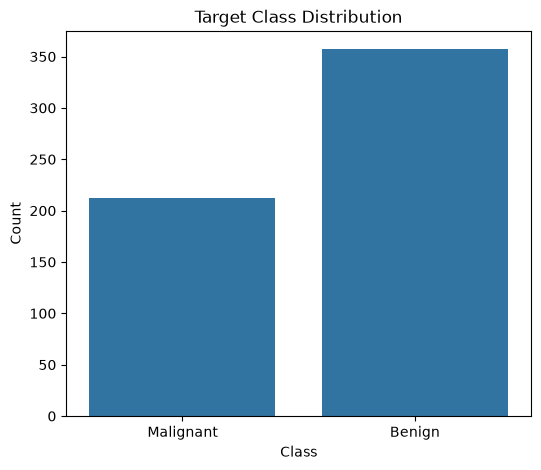

In [14]:
# Plot the target class distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(x="target", data=df)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks([0,1],["Malignant","Benign"])

plt.savefig(
    "outputs/figures/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The dataset contains two target classes.
- The distribution is reasonably balanced, making Logistic Regression suitable without significant class imbalance concerns.
- Class visualization confirms the dataset is appropriate for binary classification.

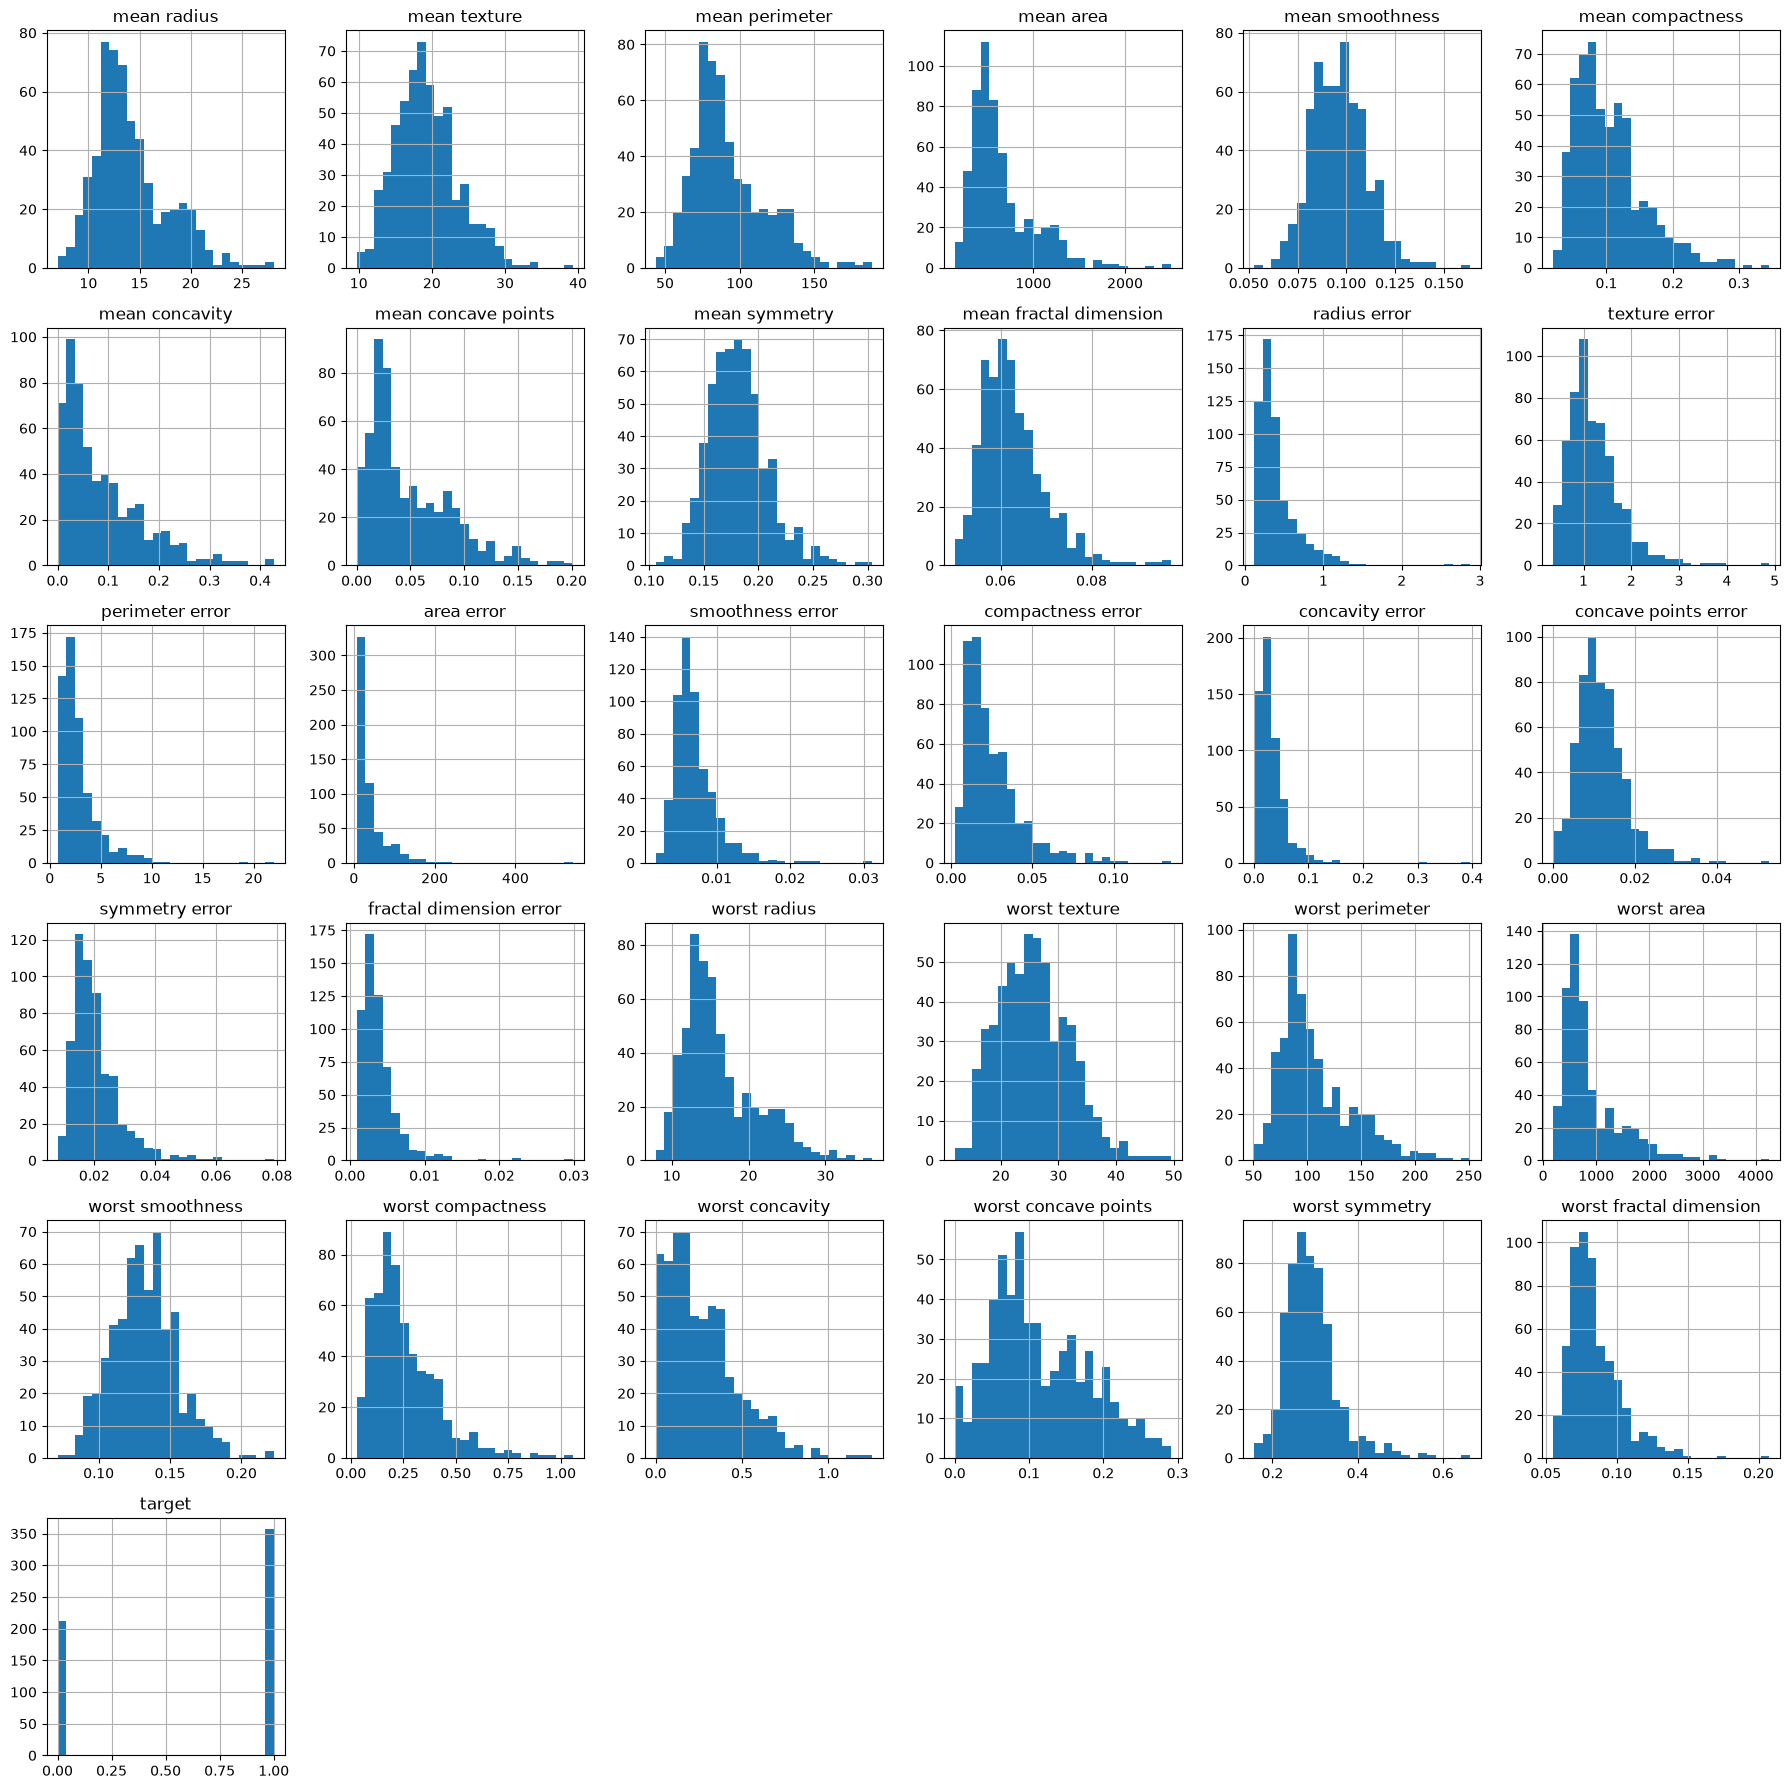

In [15]:
# Visualize feature distributions

df.hist(figsize=(18,18), bins=25)

plt.tight_layout()

plt.savefig(
    "outputs/figures/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Most numerical features exhibit different distributions.
- Several features are right-skewed.
- Feature scaling will be beneficial before training the Logistic Regression model.

In [16]:
# Compute the feature correlation matrix

correlation = df.corr()

correlation

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


In [17]:
# Save the correlation matrix

correlation.to_csv(
    "outputs/tables/correlation_matrix.csv"
)

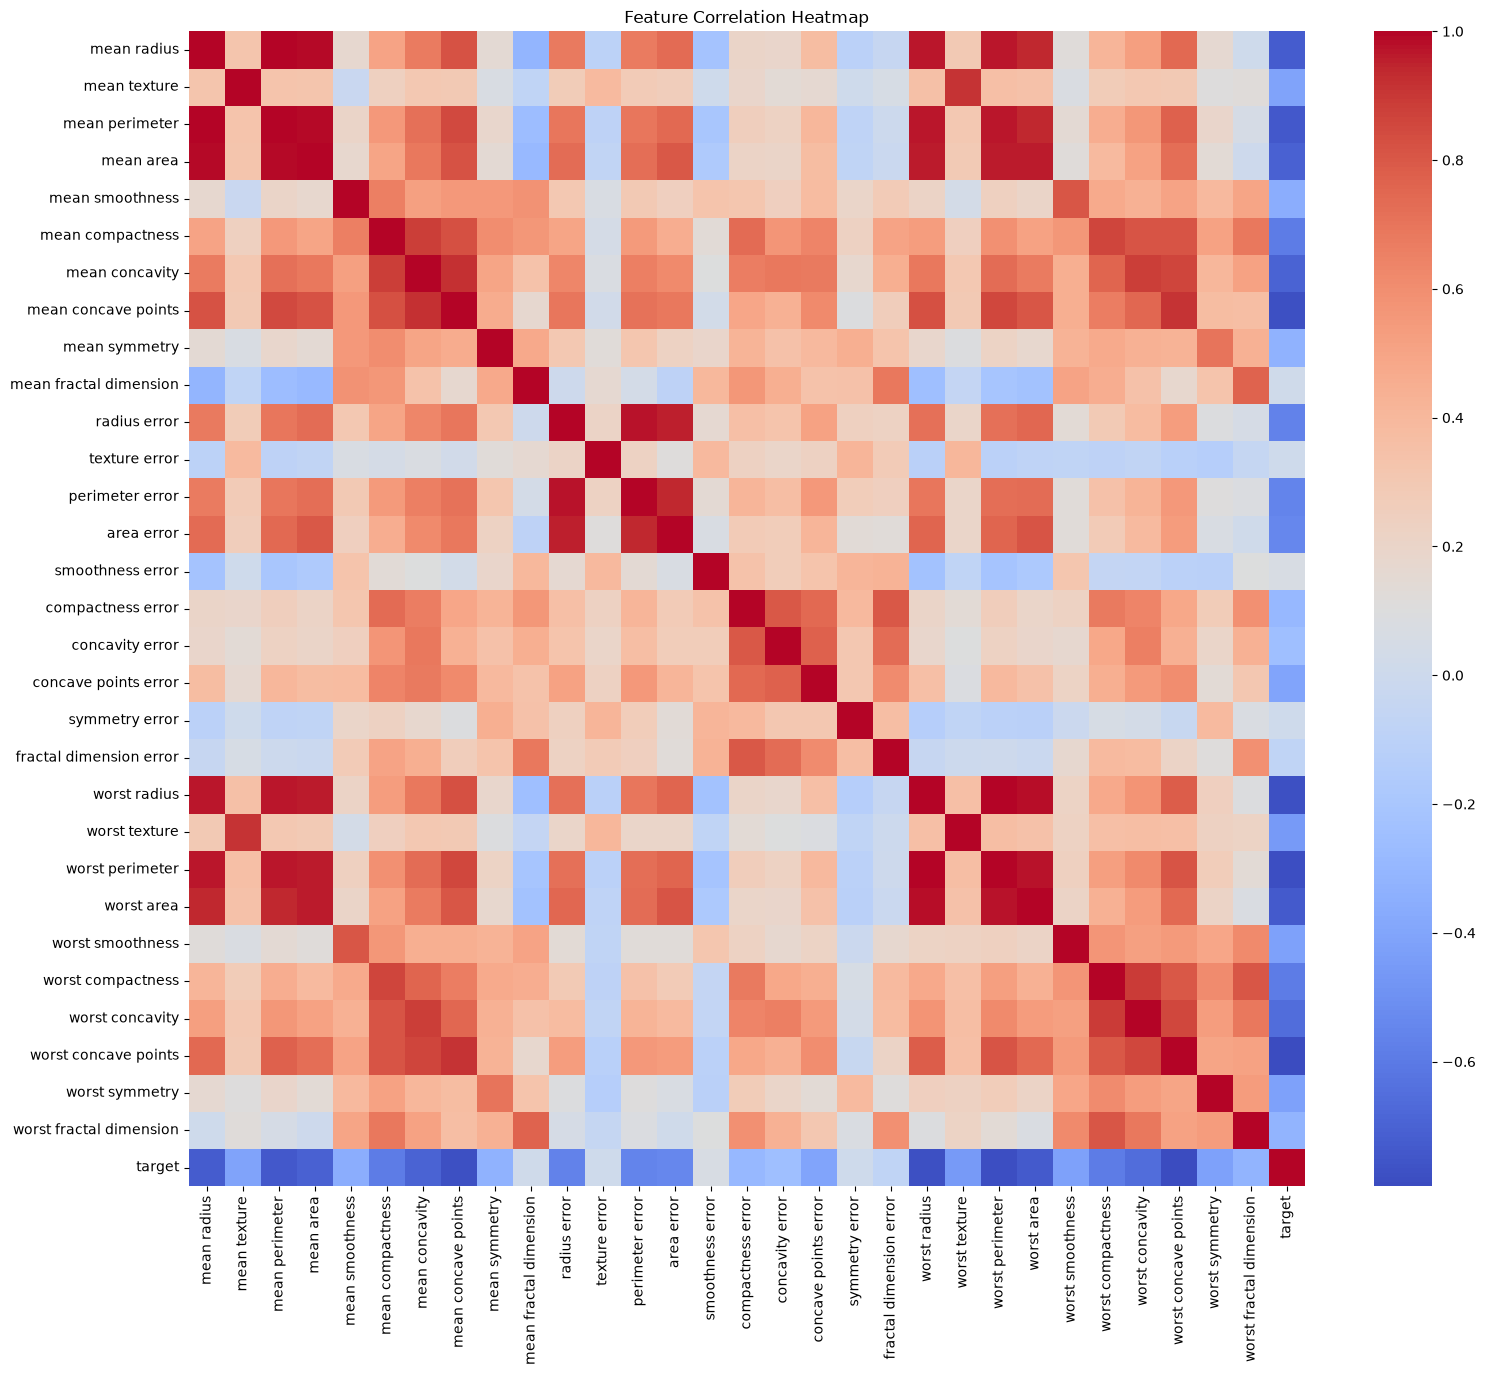

In [18]:
# Plot the correlation heatmap

plt.figure(figsize=(18,15))

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.savefig(
    "outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Several features exhibit strong positive correlations.
- Some predictors provide overlapping information.
- Logistic Regression can still perform well, although correlated features may influence coefficient interpretation.

# 5. Data Preprocessing

Before training the Logistic Regression model, the dataset is prepared by separating the input features from the target variable, splitting the data into training and testing sets, and standardizing the feature values.

Feature scaling is important because Logistic Regression performs best when numerical features are on a similar scale.

In [19]:
# Separate the features and target variable

X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (569, 30)
Target Shape : (569,)


In [20]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (455, 30)
Testing Features : (114, 30)
Training Labels : (455,)
Testing Labels : (114,)


In [21]:
# Standardize the feature values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [22]:
# Save the standardized training features

pd.DataFrame(X_train).head().to_csv(
    "outputs/tables/scaled_training_features.csv",
    index=False
)

### Insights

- The dataset has been divided into training and testing sets using an 80:20 split.
- Stratified sampling preserves the original class distribution.
- Feature scaling ensures all predictors contribute equally during model optimization.
- The processed data is now ready for model training.

# 6. Model Training

In this section, a Logistic Regression model is trained using the standardized training dataset.

The model learns the relationship between the input features and the target class by estimating the probability that a sample belongs to the positive class.

In [23]:
# Train the Logistic Regression model

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Insights

- The Logistic Regression model has been successfully trained.
- The model has learned the relationship between the standardized features and the target classes.
- It is now ready to predict unseen observations.

# 7. Prediction

The trained model is used to predict both the class labels and the probability of belonging to each class for the unseen testing dataset.

In [24]:
# Predict the target labels

y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0])

In [25]:
# Predict class probabilities

y_prob = model.predict_proba(X_test)

y_prob[:10]

array([[9.99999941e-01, 5.88824186e-08],
       [1.13351672e-05, 9.99988665e-01],
       [9.93589175e-01, 6.41082462e-03],
       [4.66491463e-01, 5.33508537e-01],
       [9.99999999e-01, 6.52500097e-10],
       [7.83960163e-03, 9.92160398e-01],
       [1.71746799e-05, 9.99982825e-01],
       [9.99999436e-01, 5.63527494e-07],
       [9.99945684e-01, 5.43163692e-05],
       [1.00000000e+00, 8.04184941e-11]])

In [26]:
# Save sample predictions

predictions = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

predictions.head(20).to_csv(
    "outputs/tables/sample_predictions.csv",
    index=False
)

### Insights

- The model successfully predicts both the target class and the probability associated with each prediction.
- Probability estimates will be used for ROC Curve analysis.

# 8. Model Evaluation

The trained Logistic Regression model is evaluated using standard classification metrics to measure its predictive performance on unseen data.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report
- ROC Curve
- AUC Score

In [27]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob[:, 1])

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

metrics

,Metric,Value
0,Accuracy,0.982456
1,Precision,0.986111
2,Recall,0.986111
3,F1 Score,0.986111
4,ROC-AUC,0.995370


In [28]:
# Save evaluation metrics

metrics.to_csv(
    "outputs/tables/evaluation_metrics.csv",
    index=False
)

### Insights

- Accuracy measures the overall prediction performance.
- Precision measures the proportion of correct positive predictions.
- Recall measures how effectively the model identifies positive cases.
- F1 Score balances Precision and Recall.
- ROC-AUC evaluates the model's ability to distinguish between classes.

In [29]:
# Generate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[41,  1],
       [ 1, 71]])

In [30]:
# Save the confusion matrix

pd.DataFrame(
    cm,
    index=["Actual Malignant","Actual Benign"],
    columns=["Predicted Malignant","Predicted Benign"]
).to_csv(
    "outputs/tables/confusion_matrix.csv"
)

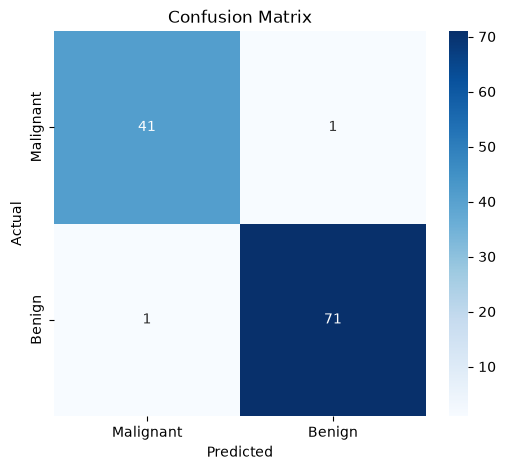

In [31]:
# Plot the confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    "outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The confusion matrix summarizes the model's correct and incorrect classifications.
- Higher values along the diagonal indicate better classification performance.
- False Positives and False Negatives help identify prediction errors.

In [32]:
# Generate the classification report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.976190,0.976190,0.976190,42.000000
1,0.986111,0.986111,0.986111,72.000000
accuracy,0.982456,0.982456,0.982456,0.982456
macro avg,0.981151,0.981151,0.981151,114.000000
weighted avg,0.982456,0.982456,0.982456,114.000000


In [33]:
# Save the classification report

report_df.to_csv(
    "outputs/tables/classification_report.csv"
)

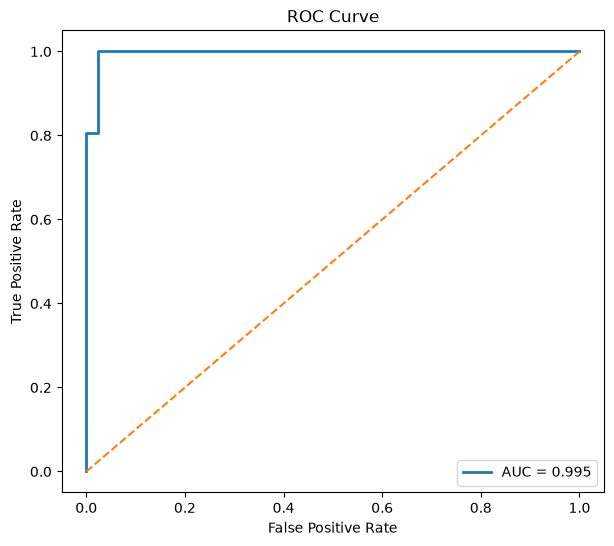

In [34]:
# Plot the ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "outputs/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The ROC Curve illustrates the trade-off between the True Positive Rate and False Positive Rate.
- A curve closer to the top-left corner indicates better classification performance.
- A higher ROC-AUC score reflects stronger discriminative capability.

# 9. Model Interpretation

Logistic Regression assigns a coefficient to each feature, indicating its contribution to the prediction.

Positive coefficients increase the likelihood of the positive class, while negative coefficients decrease it.

In [35]:
# Display feature coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients

,Feature,Coefficient
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


In [36]:
# Save feature coefficients

coefficients.to_csv(
    "outputs/tables/feature_coefficients.csv",
    index=False
)

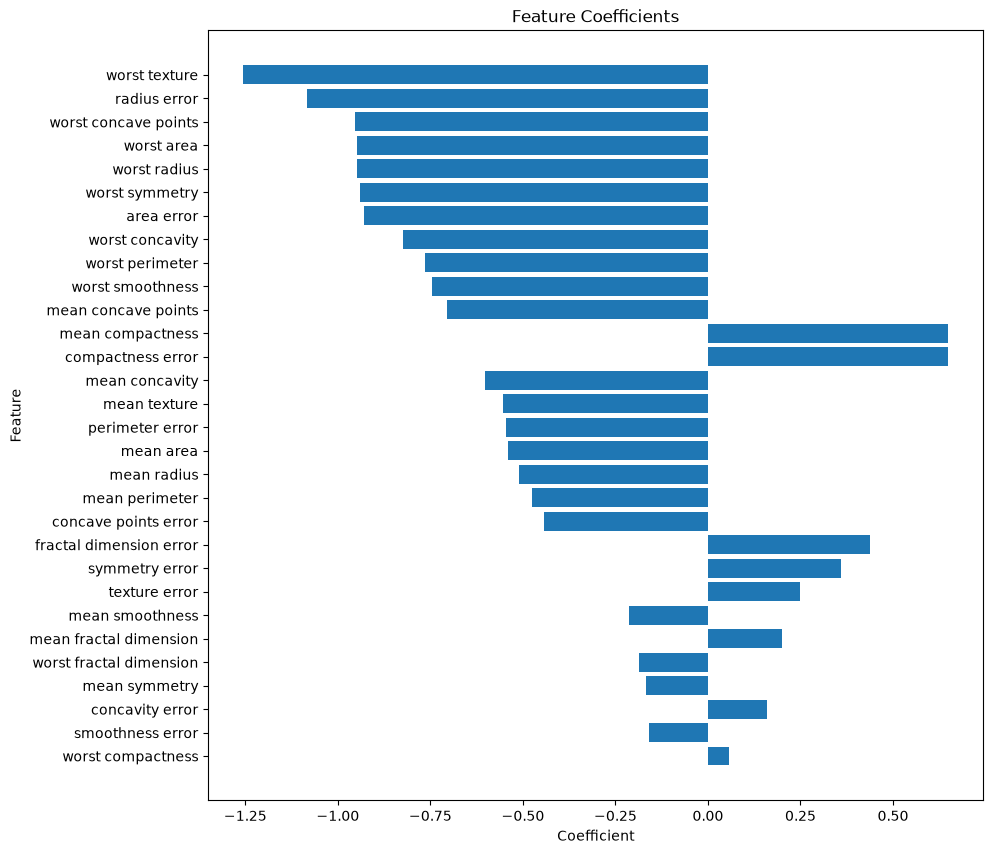

In [37]:
# Plot feature importance based on coefficients

plt.figure(figsize=(10,10))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.gca().invert_yaxis()

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients")

plt.savefig(
    "outputs/figures/feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Features with larger absolute coefficients contribute more strongly to the prediction.
- Positive coefficients increase the probability of the positive class.
- Negative coefficients decrease the probability of the positive class.

# 10. Saving the Model

The trained Logistic Regression model is saved for future predictions without retraining.

In [38]:
# Save the trained model

joblib.dump(
    model,
    "models/logistic_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [39]:
# Save the fitted scaler

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


### Insights

- The trained model has been serialized using Joblib.
- The fitted StandardScaler has also been saved to ensure consistent preprocessing during inference.

# 11. Conclusion

In this project, Logistic Regression was successfully implemented for binary classification using the Breast Cancer Wisconsin dataset.

The project covered the complete machine learning pipeline:

- Data Loading
- Exploratory Data Analysis
- Data Preprocessing
- Feature Scaling
- Model Training
- Prediction
- Model Evaluation
- Confusion Matrix
- ROC Curve
- Feature Interpretation
- Model Serialization

The trained model achieved strong classification performance and demonstrates the effectiveness of Logistic Regression for binary classification tasks.